In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
from PIL import Image
from scipy.linalg import block_diag
import random
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers

# **Neural Networks**

(a) Create and train a second network with two fully connected levels, the first level with 200 gates and the second level with 100 gates. Use sigmoid activation and the usual least squared loss function.

In [77]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def sigmoid_prime(z):
    return sigmoid(z)*(1-sigmoid(z))

class Network(object):
    def __init__(self, sizes):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y,1) for y in sizes[1:]]
        #self.biases[i][j] = b^(i+2)_j 
        #bias for jth neuron in i+2 layer

        self.weights = [np.random.randn(y,x)
                        for x,y in zip(sizes[:-1], sizes[1:])]
        
        #self.weights[i][j][k] = W^(i+2)_j^k
        #weight for connection between kth neuron in i+1 layer and 
        #jth neuron in i+2 layer
    
    def feedforward(self, a):
        #Return the output of the network if "a" is input
        for b, w in zip(self.biases, self.weights):
            #a^(i+2)_j = sigma(W^(i+2)_j^k a^(i+1)_k + b^(i+2)_j)
            a = sigmoid(np.dot(w, a)+b)
        return a
    
    def SGD(self, training_data, epochs, mini_batch_size, eta, 
            test_data=None):
        #Train the neural network using mini-batch stochastic gradient
        #descent. The "training_data" is a list of tuples (x,y)
        #representing the training inputs and the desired outputs.
        #The other non-optional parameters are self-explanatory. 
        #If "test_data" is provided then the network will be evaluated 
        #against the test data after each epoch, and partial progress
        #printed out. This is useful for tracking progress, but slows
        #things down substantially.
        if test_data: n_test = len(test_data)
        n = len(training_data)
        whichepoch = []
        accuracy_history = []
        for j in range(epochs):
            random.shuffle(training_data)
            mini_batches = [
                training_data[k:k+mini_batch_size] 
                for k in range(0, n, mini_batch_size)]
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            if test_data:
                acc = self.evaluate(test_data)
                whichepoch.append(j)
                accuracy_history.append(acc / n_test)  # store normalized accuracy
                print(f"Epoch {j}: {acc} / {n_test}")
            else:
                print(f"Epoch {j} complete")
        return whichepoch, accuracy_history

    def update_mini_batch(self, mini_batch, eta):
        #Update the network's weights and biases by applying 
        #gradient descent using backpropogation to a single mini batch.
        #The "mini_batch" is a list of tuples (x,y), and eta is the
        #learning rate.

        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)] 
        self.weights = [w-(eta/len(mini_batch))*nw
                        for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b-(eta/len(mini_batch))*nb
                       for b, nb in zip(self.biases, nabla_b)]
        
    def backprop(self, x , y):
        #Return a tuple (nabla_b, nabla_w) representing the gradient for the 
        #cost function C_x; nabla_b and nabla_w are layer-by-layer lists of numpy 
        #arrays, similar to self.biases and self.weights.

        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        #feed forward
        activation = x
        activations = [x] #list to store all the activations, layer by layer
        zs = [] #list to store all the z vectors, layer by layer
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)

        #backward pass
        delta = self.cost_derivative(activations[-1],y) * \
                sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)

        #in the loop below, l=1 means the last layer of neurons, 
        # l=2 is the second-last layer, and so on
        for l in range(2,self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].T, delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].T)
        return (nabla_b, nabla_w)
    
    def evaluate(self, test_data):
        #Return the number of test inputs for which the neural network outputs the 
        #correct result. Note that the neural network's output is assumed to be the 
        #index of whichever neuron in the final layer has the highest activation.
        test_results = [(np.argmax(self.feedforward(x)), y)
                        for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)
    
    def cost_derivative(self, output_activations, y):
        #Return the vector of partial derivatives \partial C_x / 
        #\partial a for the output activations.
        return (output_activations - y)

In [75]:
def load_data_wrapper():
    tr_d, te_d = mnist.load_data()
    training_inputs = [np.reshape(x/255.0, (784, 1)) for x in tr_d[0]]
    training_results = [vectorized_result(y) for y in tr_d[1]]
    training_data = list(zip(training_inputs, training_results))
    test_inputs = [np.reshape(x/255.0, (784, 1)) for x in te_d[0]]
    test_data = list(zip(test_inputs, te_d[1]))
    return (training_data, test_data)

def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

training_data, test_data = load_data_wrapper()

In [78]:
net = Network([784, 200, 100, 10])
epochs, accuracy = net.SGD(training_data, 30, 32, 0.1, test_data=test_data)

Epoch 0: 3903 / 10000
Epoch 1: 4953 / 10000
Epoch 2: 5617 / 10000
Epoch 3: 5980 / 10000
Epoch 4: 6294 / 10000
Epoch 5: 6823 / 10000
Epoch 6: 7211 / 10000
Epoch 7: 7439 / 10000
Epoch 8: 7541 / 10000
Epoch 9: 7646 / 10000
Epoch 10: 7722 / 10000
Epoch 11: 7780 / 10000
Epoch 12: 7851 / 10000
Epoch 13: 7896 / 10000
Epoch 14: 7931 / 10000
Epoch 15: 7970 / 10000
Epoch 16: 7993 / 10000
Epoch 17: 8016 / 10000
Epoch 18: 8037 / 10000
Epoch 19: 8070 / 10000
Epoch 20: 8088 / 10000
Epoch 21: 8099 / 10000
Epoch 22: 8119 / 10000
Epoch 23: 8140 / 10000
Epoch 24: 8153 / 10000
Epoch 25: 8166 / 10000
Epoch 26: 8181 / 10000
Epoch 27: 8189 / 10000
Epoch 28: 8206 / 10000
Epoch 29: 8211 / 10000


(b) Create and train a simple deep learning network consisting of a convolution level with pooling, a fully connected level, and then softmax. Keep the network small. Use 20 channels for the convolution level and 100 gates for the fully connected level. For input data, use the MNIST data set with $28\times28$ images of digits.

In [61]:
model = keras.Sequential([
    # Convolutional layer with 20 channels, 5 x 5 window size
    layers.Conv2D(filters=20, kernel_size=(5,5), activation='sigmoid',
                  input_shape=(28,28,1)),

    # Pooling 2 x 2 window size
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten
    layers.Flatten(),

    # Fully connected level with 100 gates
    layers.Dense(100, activation='sigmoid'),

    # Output (softmax built-in here)
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='mean_squared_error',
    metrics=['accuracy']
)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension (VERY IMPORTANT)
x_train = x_train[..., tensorflow.newaxis]
x_test = x_test[..., tensorflow.newaxis]

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

history_conv = model.fit(x_train, y_train, epochs=30, batch_size=32)
epochs_conv = list(range(len(history_conv.history['accuracy'])))



Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1252 - loss: 0.0899
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1783 - loss: 0.0894
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2400 - loss: 0.0880
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3219 - loss: 0.0824
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5706 - loss: 0.0671
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7201 - loss: 0.0481
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8174 - loss: 0.0348
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8524 - loss: 0.0275
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8686 - loss: 0.0233
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8787 - loss: 0.0208
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8860 - loss: 0.0191
Epoch 12/30
1875/1875 ━━━━━━━━

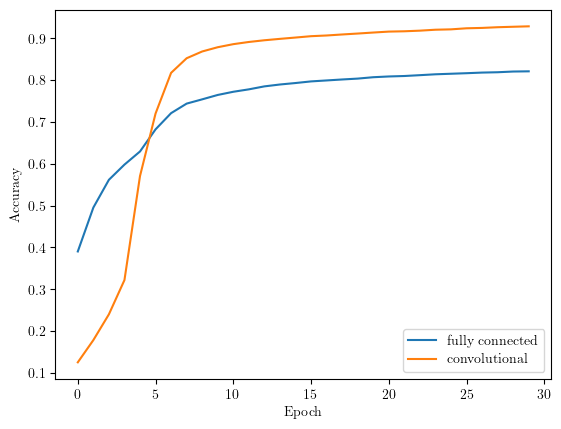

In [89]:
accuracy_conv = history_conv.history['accuracy']
plt.plot(epochs, accuracy, label = 'fully connected')
plt.plot(epochs_conv, accuracy_conv, label = 'convolutional')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()